In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv(r"C:\Users\abbas\OneDrive\Desktop\Kaggle Competition\playground-series-s6e8\train.csv")
test = pd.read_csv(r"C:\Users\abbas\OneDrive\Desktop\Kaggle Competition\playground-series-s6e8\test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTarget counts:")
print(train["addicted_label"].value_counts())
print("\nTarget percentages:")
print(train["addicted_label"].value_counts(normalize=True))
print("\nMissing values in train:")
print(train.isnull().sum().sort_values(ascending=False))
print("\nMissing values in test:")
print(test.isnull().sum().sort_values(ascending=False))
print("\nDuplicate rows in train:", train.duplicated().sum())
print("\nColumn data types:")
print(train.dtypes)

train_id = train["id"]
test_id = test["id"]
train = train.drop(columns=["id"])
test = test.drop(columns=["id"])

print("\nTrain shape after dropping id:", train.shape)
print("Test shape after dropping id:", test.shape)

Train shape: (691369, 14)
Test shape: (296302, 13)

Target counts:
addicted_label
1    490474
0    200895
Name: count, dtype: int64

Target percentages:
addicted_label
1    0.709424
0    0.290576
Name: proportion, dtype: float64

Missing values in train:
social_media_hours         133995
gaming_hours               126821
weekend_screen_time        112063
daily_screen_time_hours     95854
app_opens_per_day           80710
notifications_per_day       67584
stress_level                55148
work_study_hours            51518
sleep_hours                 44480
academic_work_impact        44224
gender                      29034
age                         28929
id                              0
addicted_label                  0
dtype: int64

Missing values in test:
gaming_hours               59420
weekend_screen_time        50697
social_media_hours         47397
notifications_per_day      34221
daily_screen_time_hours    32788
work_study_hours           27777
academic_work_impact       25721


In [2]:
target = "addicted_label"

numeric_features = train.select_dtypes(include="number").columns.drop(target).tolist()
categorical_features = train.select_dtypes(include="str").columns.tolist()

print("NUMERIC FEATURES: MEAN BY TARGET")
print(train.groupby(target)[numeric_features].mean().T.round(2))

print("\nCATEGORICAL FEATURES: ADDICTION RATE BY CATEGORY")
for column in categorical_features:
    print(f"\n{column}")
    print(train.groupby(column, dropna=False)[target].agg(["mean", "count"]).round(4))

print("\nMISSINGNESS RATE BY TARGET")
for column in numeric_features + categorical_features:
    missing_rate = train.groupby(target)[column].apply(lambda values: values.isna().mean())
    print(f"{column}: {missing_rate.round(4).to_dict()}")

print("\nNUMERIC CORRELATION WITH TARGET")
print(train[numeric_features + [target]].corr()[target].drop(target).sort_values(ascending=False).round(4))

NUMERIC FEATURES: MEAN BY TARGET
addicted_label                0       1
age                       26.58   26.63
daily_screen_time_hours    5.04    8.71
social_media_hours         1.38    2.92
gaming_hours               1.16    1.58
work_study_hours           1.87    2.57
sleep_hours                6.72    6.84
notifications_per_day    147.09  145.41
app_opens_per_day         97.87  104.59
weekend_screen_time        6.85   10.56

CATEGORICAL FEATURES: ADDICTION RATE BY CATEGORY

gender
          mean   count
gender                
Female  0.7038  221595
Male    0.7232  223662
Other   0.7010  217078
NaN     0.7088   29034

stress_level
                mean   count
stress_level                
High          0.7114  220873
Low           0.7112  207783
Medium        0.7057  207565
NaN           0.7090   55148

academic_work_impact
                        mean   count
academic_work_impact                
No                    0.7110  316579
Yes                   0.7079  330566
NaN          

NUMERIC FEATURE DISTRIBUTIONS

age


{'missing': 28929, 'missing_percent': np.float64(4.18), 'unique': 18, 'min': np.float64(18.0), 'median': np.float64(27.0), 'mean': np.float64(26.62), 'max': np.float64(35.0), 'skewness': np.float64(-0.04)}


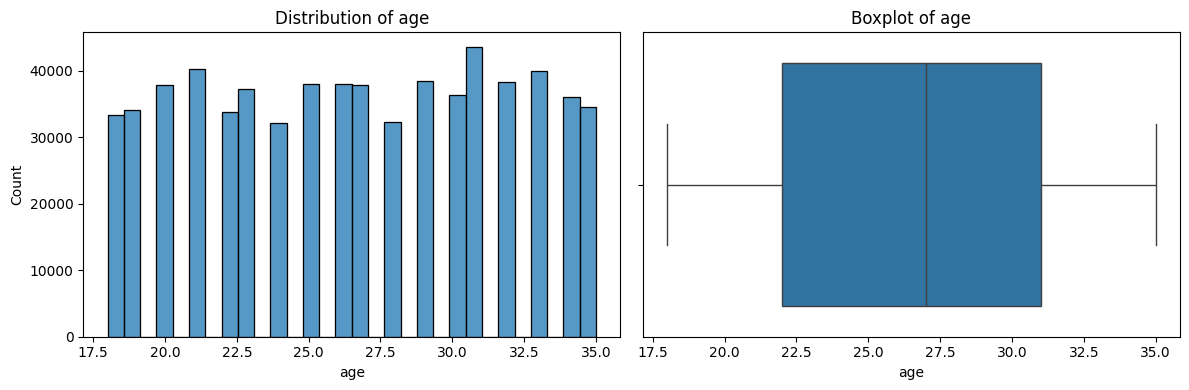


daily_screen_time_hours
{'missing': 95854, 'missing_percent': np.float64(13.86), 'unique': 1389, 'min': np.float64(0.5), 'median': np.float64(7.77), 'mean': np.float64(7.64), 'max': np.float64(15.0), 'skewness': np.float64(-0.13)}


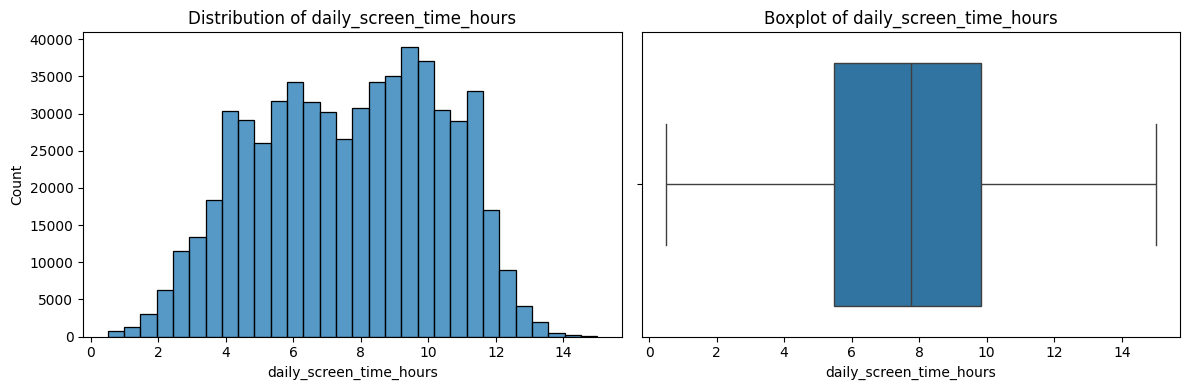


social_media_hours
{'missing': 133995, 'missing_percent': np.float64(19.38), 'unique': 721, 'min': np.float64(0.0), 'median': np.float64(2.31), 'mean': np.float64(2.47), 'max': np.float64(8.0), 'skewness': np.float64(0.47)}


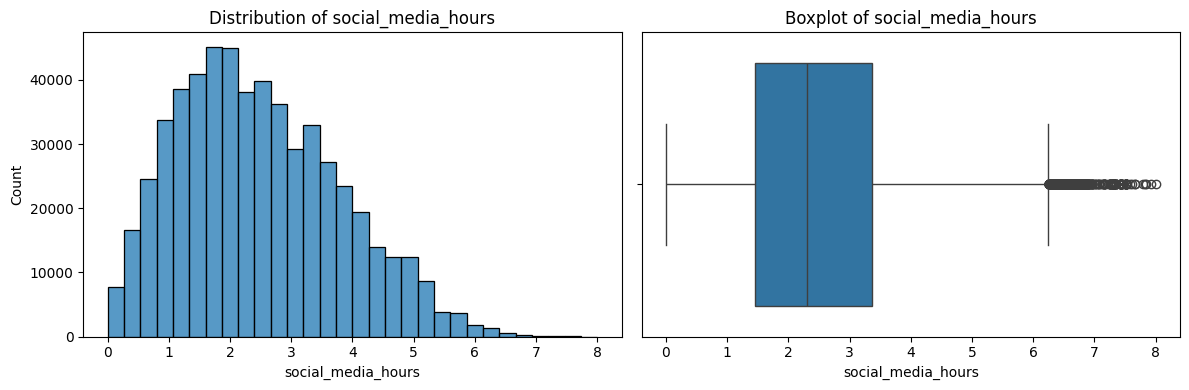


gaming_hours
{'missing': 126821, 'missing_percent': np.float64(18.34), 'unique': 401, 'min': np.float64(0.0), 'median': np.float64(1.33), 'mean': np.float64(1.46), 'max': np.float64(4.0), 'skewness': np.float64(0.54)}


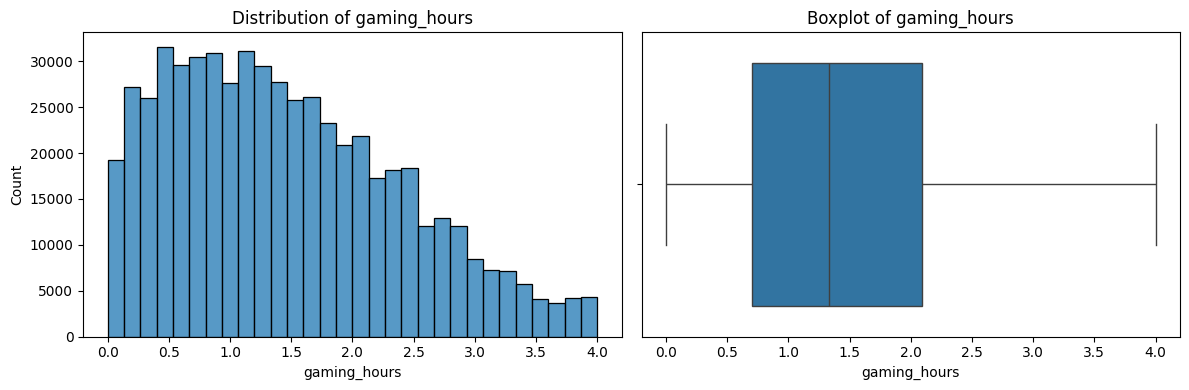


work_study_hours
{'missing': 51518, 'missing_percent': np.float64(7.45), 'unique': 600, 'min': np.float64(0.0), 'median': np.float64(2.2), 'mean': np.float64(2.37), 'max': np.float64(6.0), 'skewness': np.float64(0.56)}


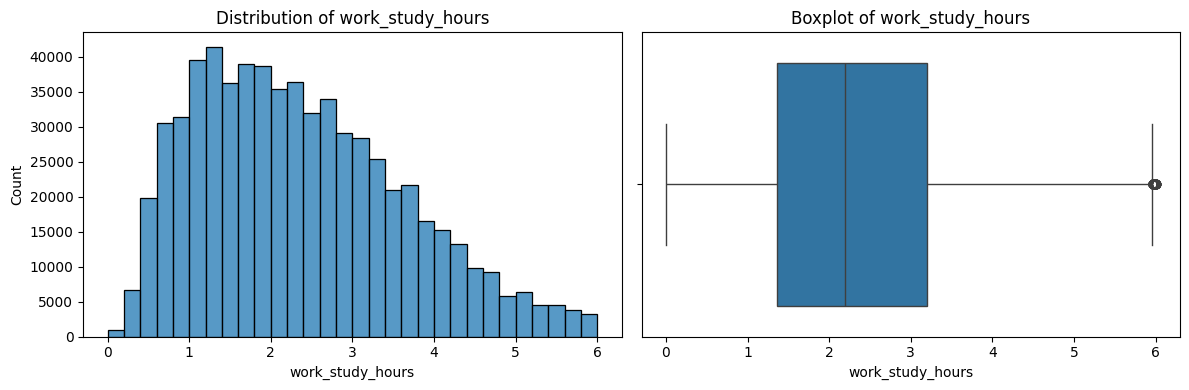


sleep_hours
{'missing': 44480, 'missing_percent': np.float64(6.43), 'unique': 451, 'min': np.float64(4.5), 'median': np.float64(6.8), 'mean': np.float64(6.8), 'max': np.float64(9.0), 'skewness': np.float64(-0.01)}


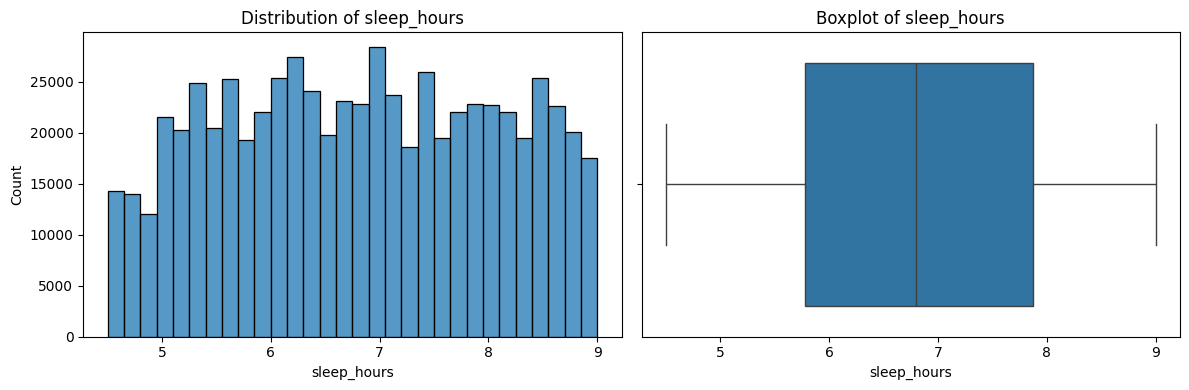


notifications_per_day
{'missing': 67584, 'missing_percent': np.float64(9.78), 'unique': 231, 'min': np.float64(20.0), 'median': np.float64(150.0), 'mean': np.float64(145.89), 'max': np.float64(250.0), 'skewness': np.float64(-0.21)}


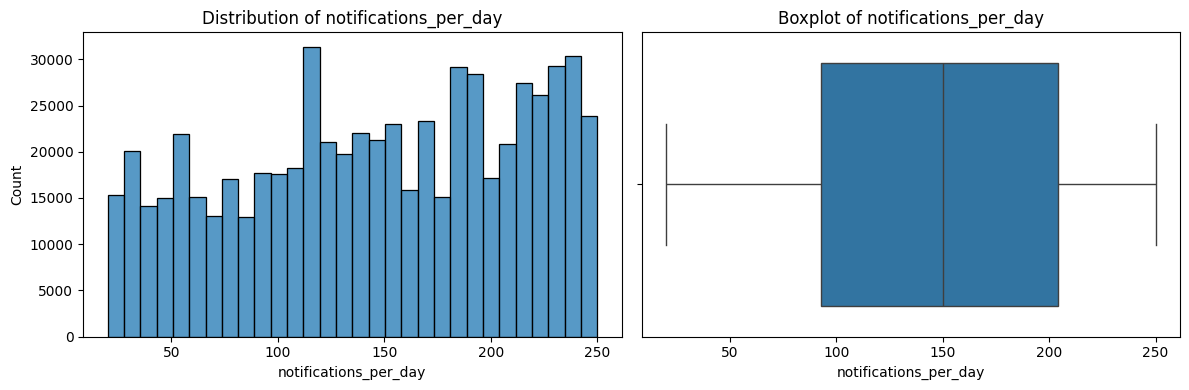


app_opens_per_day
{'missing': 80710, 'missing_percent': np.float64(11.67), 'unique': 166, 'min': np.float64(15.0), 'median': np.float64(104.0), 'mean': np.float64(102.64), 'max': np.float64(180.0), 'skewness': np.float64(-0.13)}


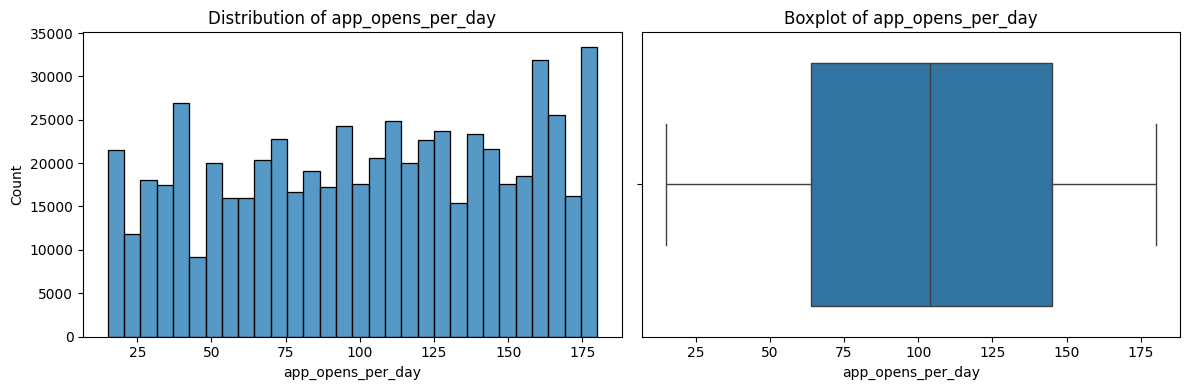


weekend_screen_time
{'missing': 112063, 'missing_percent': np.float64(16.21), 'unique': 1437, 'min': np.float64(0.51), 'median': np.float64(9.58), 'mean': np.float64(9.48), 'max': np.float64(17.56), 'skewness': np.float64(-0.06)}


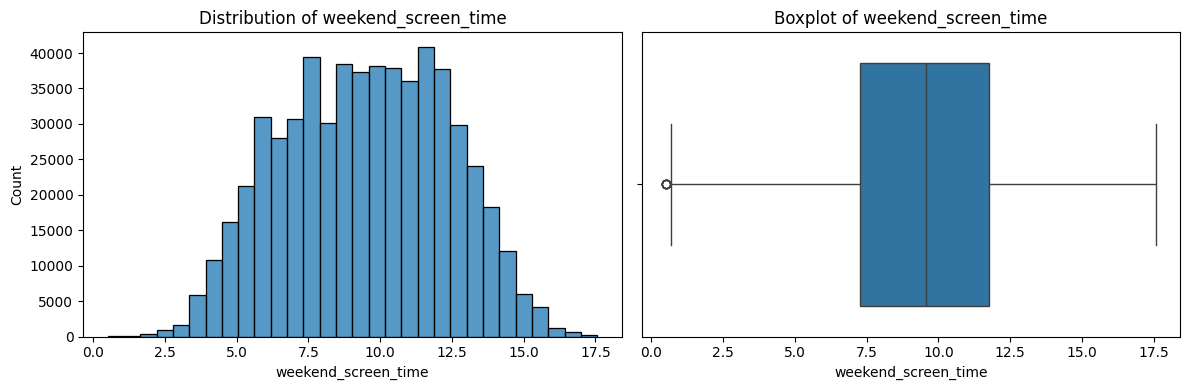

CATEGORICAL FEATURE DISTRIBUTIONS

gender
Missing: 29034
Unique values: 3
gender
Male       223662
Female     221595
Other      217078
Missing     29034
Name: count, dtype: int64


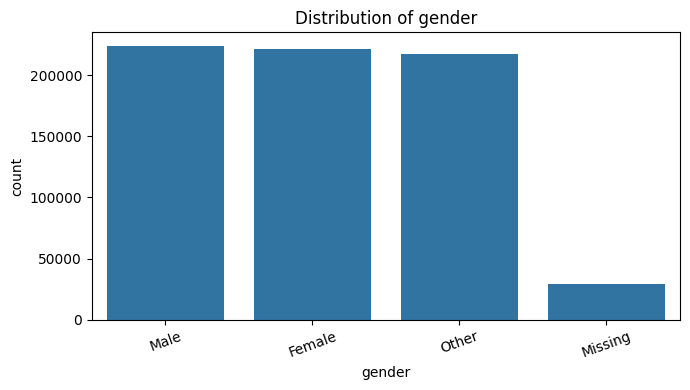


stress_level
Missing: 55148
Unique values: 3
stress_level
High       220873
Low        207783
Medium     207565
Missing     55148
Name: count, dtype: int64


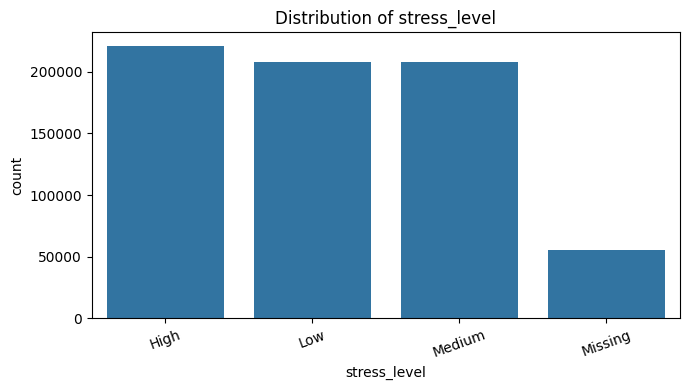


academic_work_impact
Missing: 44224
Unique values: 2
academic_work_impact
Yes        330566
No         316579
Missing     44224
Name: count, dtype: int64


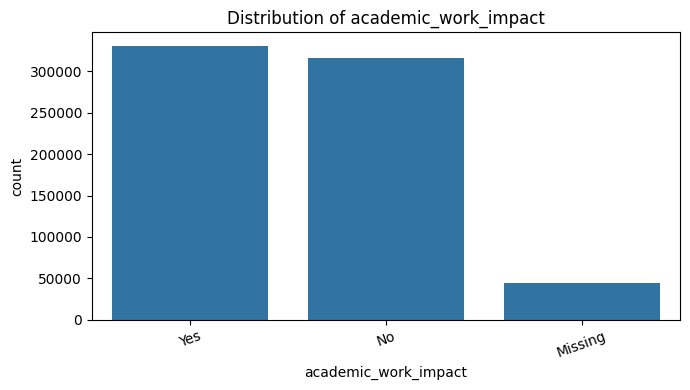

In [3]:
print("NUMERIC FEATURE DISTRIBUTIONS")
for column in numeric_features:
    series = train[column]
    print(f"\n{column}")
    print({
        "missing": int(series.isna().sum()),
        "missing_percent": round(series.isna().mean() * 100, 2),
        "unique": int(series.nunique()),
        "min": series.min(),
        "median": series.median(),
        "mean": round(series.mean(), 2),
        "max": series.max(),
        "skewness": round(series.skew(), 2),
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(series, bins=30, ax=axes[0])
    axes[0].set_title(f"Distribution of {column}")
    sns.boxplot(x=series, ax=axes[1])
    axes[1].set_title(f"Boxplot of {column}")
    plt.tight_layout()
    plt.show()

print("CATEGORICAL FEATURE DISTRIBUTIONS")
for column in categorical_features:
    plot_series = train[column].fillna("Missing")
    print(f"\n{column}")
    print("Missing:", int(train[column].isna().sum()))
    print("Unique values:", int(train[column].nunique(dropna=True)))
    print(plot_series.value_counts())

    plt.figure(figsize=(7, 4))
    order = plot_series.value_counts().index
    sns.countplot(x=plot_series, order=order)
    plt.title(f"Distribution of {column}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

NUMERIC FEATURES VS TARGET

age
                 mean  median   std
addicted_label                     
0               26.58    27.0  5.25
1               26.63    27.0  5.11


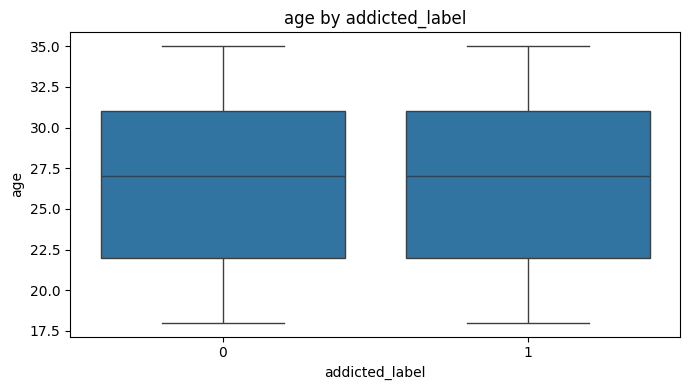


daily_screen_time_hours
                mean  median   std
addicted_label                    
0               5.04    5.04  1.62
1               8.71    9.07  2.34


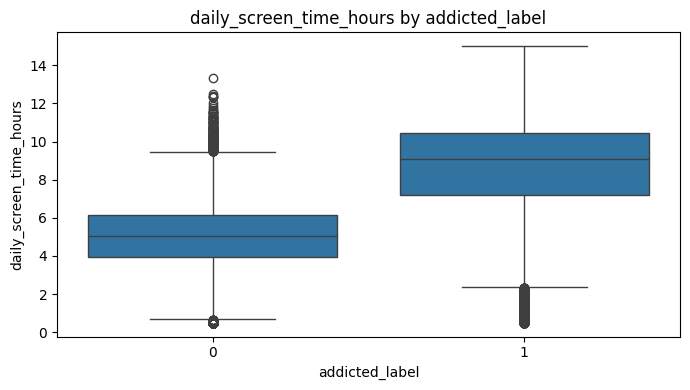


social_media_hours
                mean  median   std
addicted_label                    
0               1.38    1.29  0.74
1               2.92    2.82  1.24


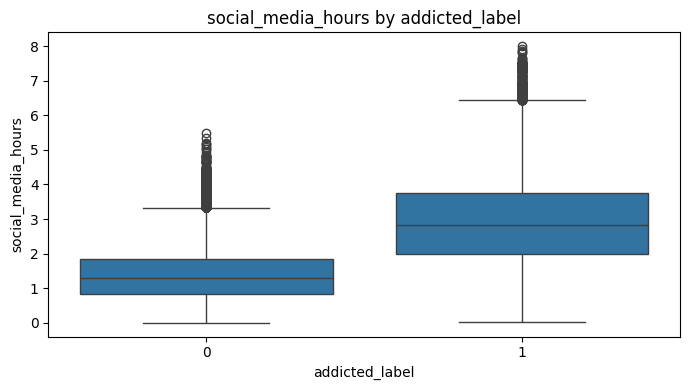


gaming_hours
                mean  median   std
addicted_label                    
0               1.16    1.07  0.74
1               1.58    1.48  0.98


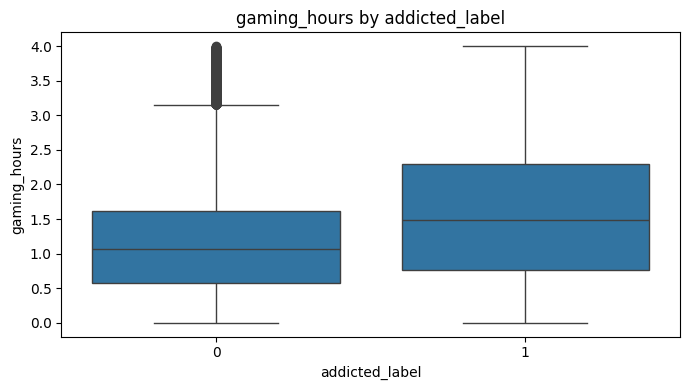


work_study_hours
                mean  median   std
addicted_label                    
0               1.87    1.75  0.97
1               2.57    2.47  1.31


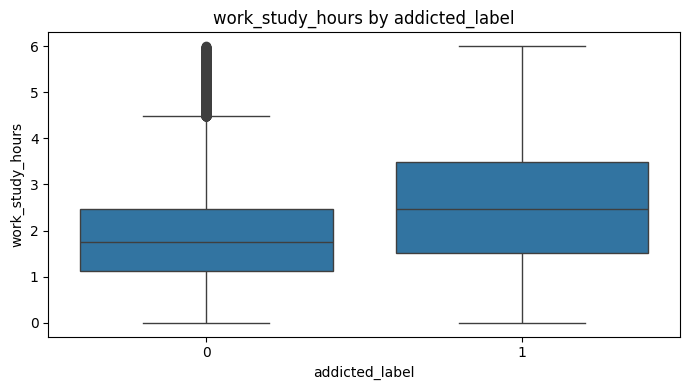


sleep_hours
                mean  median   std
addicted_label                    
0               6.72    6.72  1.24
1               6.84    6.84  1.23


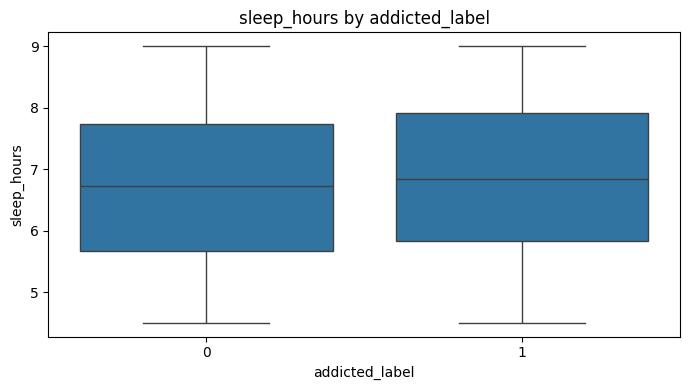


notifications_per_day
                  mean  median    std
addicted_label                       
0               147.09   154.0  65.98
1               145.41   150.0  65.89


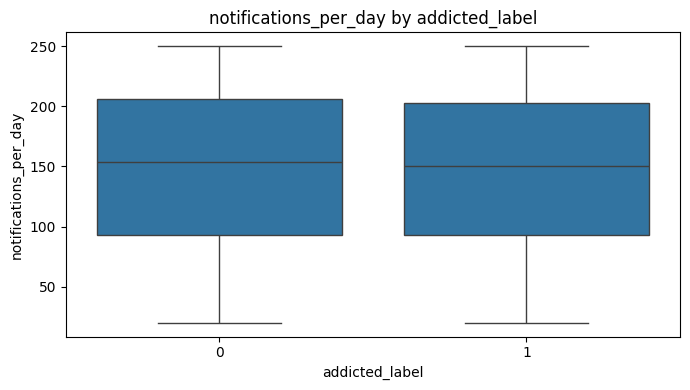


app_opens_per_day
                  mean  median    std
addicted_label                       
0                97.87    99.0  47.38
1               104.59   109.0  48.25


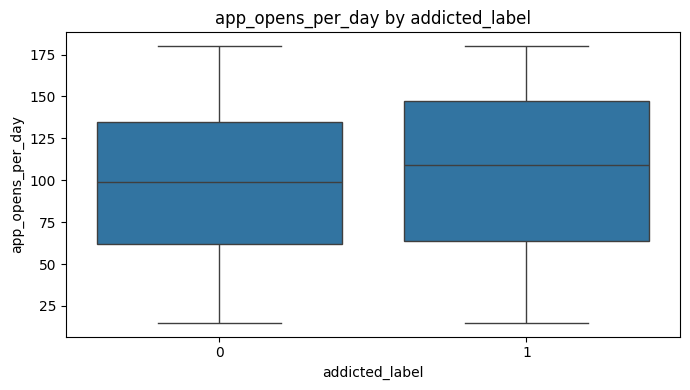


weekend_screen_time
                 mean  median   std
addicted_label                     
0                6.85    6.82  1.76
1               10.56   10.79  2.50


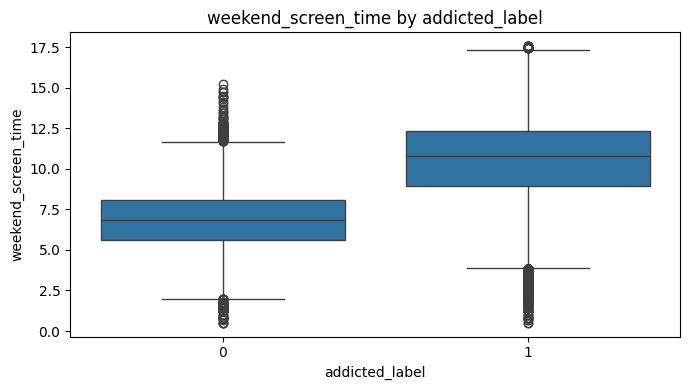

CATEGORICAL FEATURES VS TARGET

gender
           mean   count
gender                 
Male     0.7232  223662
Missing  0.7088   29034
Female   0.7038  221595
Other    0.7010  217078


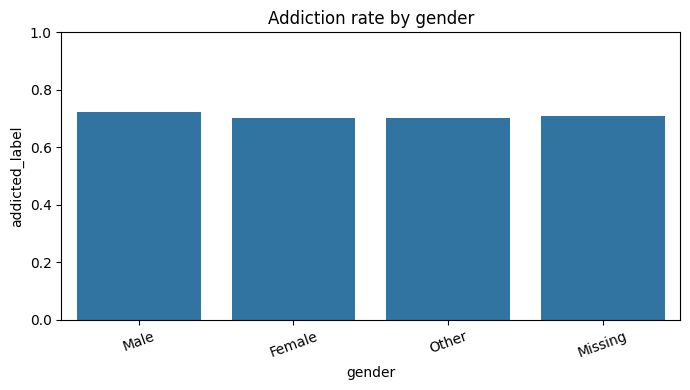


stress_level
                mean   count
stress_level                
High          0.7114  220873
Low           0.7112  207783
Missing       0.7090   55148
Medium        0.7057  207565


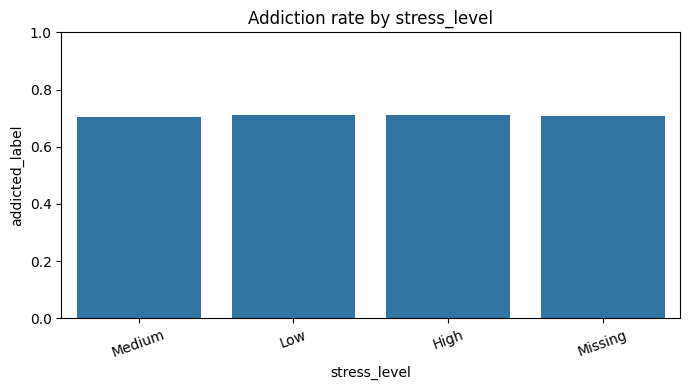


academic_work_impact
                        mean   count
academic_work_impact                
No                    0.7110  316579
Missing               0.7095   44224
Yes                   0.7079  330566


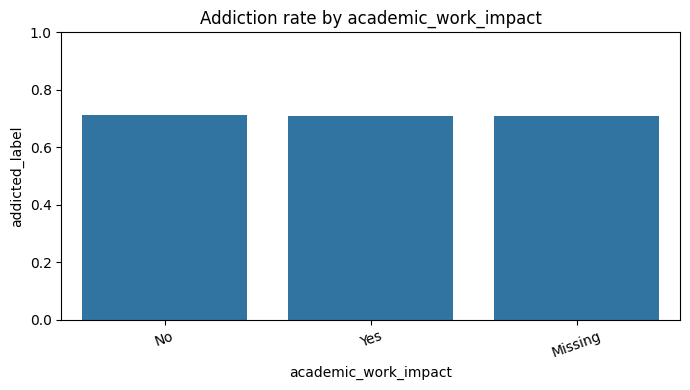

In [4]:
print("NUMERIC FEATURES VS TARGET")
for column in numeric_features:
    print(f"\n{column}")
    print(train.groupby(target)[column].agg(["mean", "median", "std"]).round(2))

    plt.figure(figsize=(7, 4))
    sns.boxplot(data=train, x=target, y=column)
    plt.title(f"{column} by {target}")
    plt.tight_layout()
    plt.show()

print("CATEGORICAL FEATURES VS TARGET")
for column in categorical_features:
    analysis_data = train[[column, target]].copy()
    analysis_data[column] = analysis_data[column].fillna("Missing")
    category_summary = analysis_data.groupby(column)[target].agg(["mean", "count"]).sort_values("mean", ascending=False)

    print(f"\n{column}")
    print(category_summary.round(4))

    plt.figure(figsize=(7, 4))
    sns.barplot(data=analysis_data, x=column, y=target, estimator="mean", errorbar=None)
    plt.title(f"Addiction rate by {column}")
    plt.xticks(rotation=20)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

CATEGORICAL FEATURE ANALYSIS

gender
         category_count  category_percent  addiction_rate
gender                                                   
Male             223662             32.35          0.7232
Missing           29034              4.20          0.7088
Female           221595             32.05          0.7038
Other            217078             31.40          0.7010


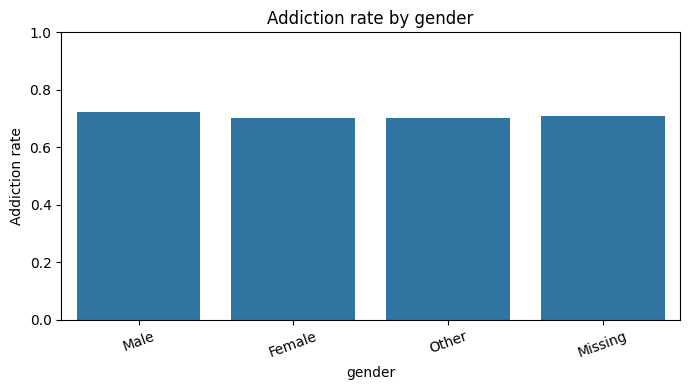


stress_level
              category_count  category_percent  addiction_rate
stress_level                                                  
High                  220873             31.95          0.7114
Low                   207783             30.05          0.7112
Missing                55148              7.98          0.7090
Medium                207565             30.02          0.7057


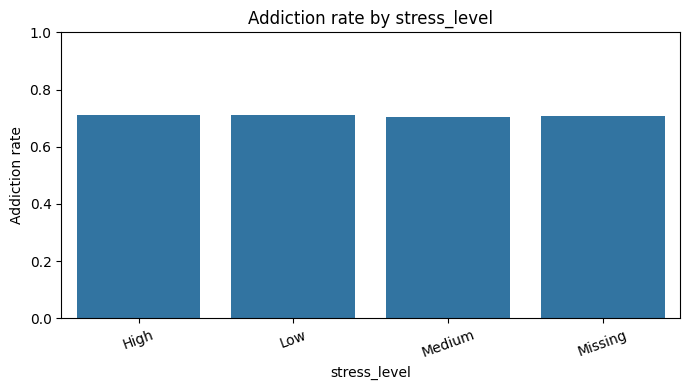


academic_work_impact
                      category_count  category_percent  addiction_rate
academic_work_impact                                                  
No                            316579             45.79          0.7110
Missing                        44224              6.40          0.7095
Yes                           330566             47.81          0.7079


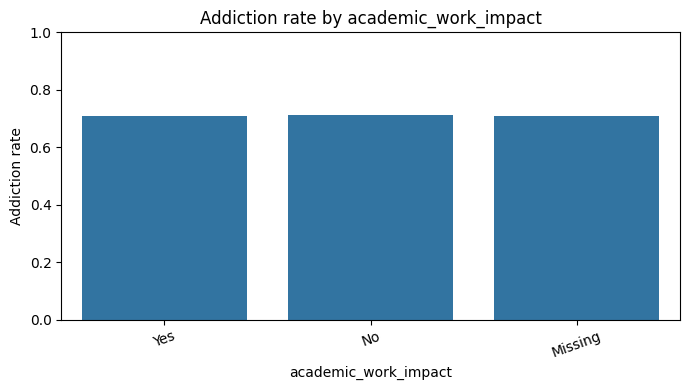

In [5]:
print("CATEGORICAL FEATURE ANALYSIS")

for column in categorical_features:
    analysis_data = train[[column, target]].copy()
    analysis_data[column] = analysis_data[column].fillna("Missing")

    summary = analysis_data.groupby(column, observed=False)[target].agg(
        category_count="count",
        addiction_rate="mean"
    )
    summary["category_percent"] = summary["category_count"] / len(analysis_data) * 100
    summary = summary[["category_count", "category_percent", "addiction_rate"]]
    summary["category_percent"] = summary["category_percent"].round(2)
    summary["addiction_rate"] = summary["addiction_rate"].round(4)

    print(f"\n{column}")
    print(summary.sort_values("addiction_rate", ascending=False))

    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=analysis_data,
        x=column,
        y=target,
        estimator="mean",
        errorbar=None,
        order=analysis_data[column].value_counts().index
    )
    plt.title(f"Addiction rate by {column}")
    plt.ylabel("Addiction rate")
    plt.ylim(0, 1)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

NUMERICAL FEATURE ANALYSIS
                feature  missing_percent  mean_not_addicted  mean_addicted  median_not_addicted  median_addicted    q1     q3  skewness  effect_size
daily_screen_time_hours            13.86               5.04           8.71                 5.04             9.07  5.48   9.84     -0.13        1.822
    weekend_screen_time            16.21               6.85          10.56                 6.82            10.79  7.28  11.75     -0.06        1.719
     social_media_hours            19.38               1.38           2.92                 1.29             2.82  1.45   3.37      0.47        1.516
       work_study_hours             7.45               1.87           2.57                 1.75             2.47  1.36   3.20      0.56        0.606
           gaming_hours            18.34               1.16           1.58                 1.07             1.48  0.70   2.09      0.54        0.488
      app_opens_per_day            11.67              97.87         104.59     

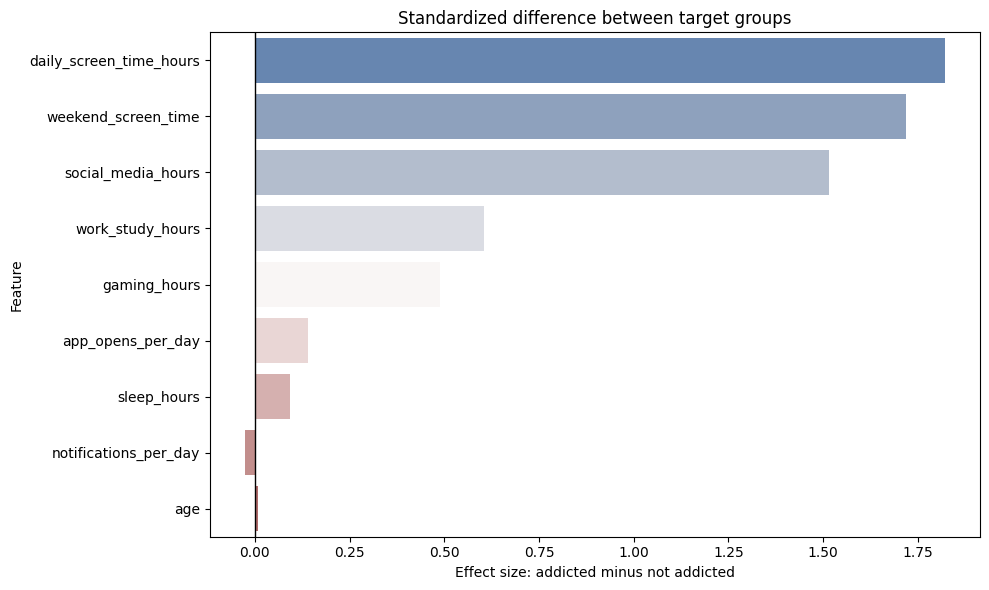

In [6]:
print("NUMERICAL FEATURE ANALYSIS")

numeric_analysis = []

for column in numeric_features:
    non_addicted = train.loc[train[target] == 0, column].dropna()
    addicted = train.loc[train[target] == 1, column].dropna()

    pooled_std = np.sqrt((non_addicted.var() + addicted.var()) / 2)
    effect_size = (addicted.mean() - non_addicted.mean()) / pooled_std

    numeric_analysis.append({
        "feature": column,
        "missing_percent": round(train[column].isna().mean() * 100, 2),
        "mean_not_addicted": round(non_addicted.mean(), 2),
        "mean_addicted": round(addicted.mean(), 2),
        "median_not_addicted": round(non_addicted.median(), 2),
        "median_addicted": round(addicted.median(), 2),
        "q1": round(train[column].quantile(0.25), 2),
        "q3": round(train[column].quantile(0.75), 2),
        "skewness": round(train[column].skew(), 2),
        "effect_size": round(effect_size, 3),
    })

numeric_analysis_df = pd.DataFrame(numeric_analysis).sort_values(
    "effect_size",
    key=lambda values: values.abs(),
    ascending=False,
)

print(numeric_analysis_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=numeric_analysis_df,
    x="effect_size",
    y="feature",
    hue="feature",
    palette="vlag",
    legend=False,
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Standardized difference between target groups")
plt.xlabel("Effect size: addicted minus not addicted")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

MEANS AND MEDIANS BY TARGET
                  age        daily_screen_time_hours         \
                 mean median                    mean median   
addicted_label                                                
0               26.58   27.0                    5.04   5.04   
1               26.63   27.0                    8.71   9.07   

               social_media_hours        gaming_hours        work_study_hours  \
                             mean median         mean median             mean   
addicted_label                                                                  
0                            1.38   1.29         1.16   1.07             1.87   
1                            2.92   2.82         1.58   1.48             2.57   

                      sleep_hours        notifications_per_day         \
               median        mean median                  mean median   
addicted_label                                                          
0                1.75        6.

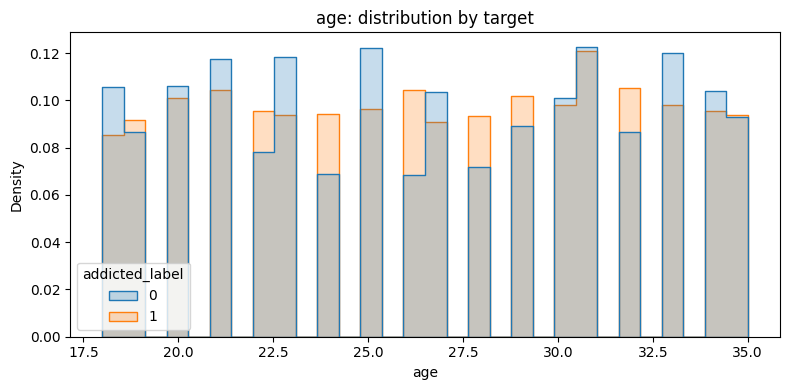

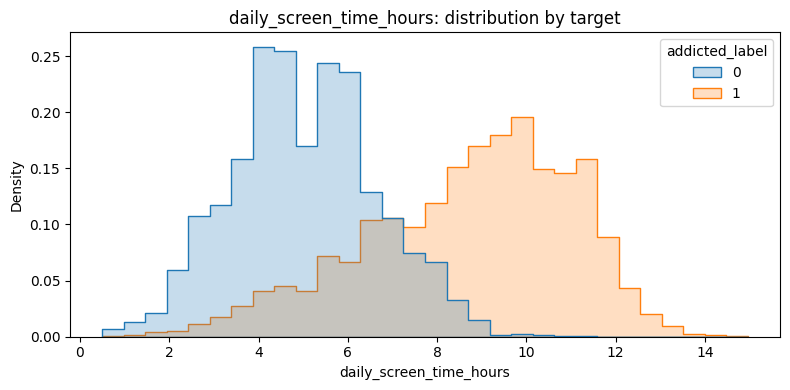

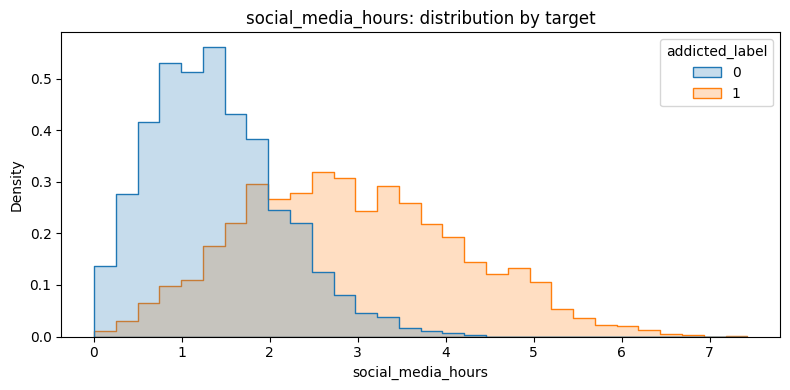

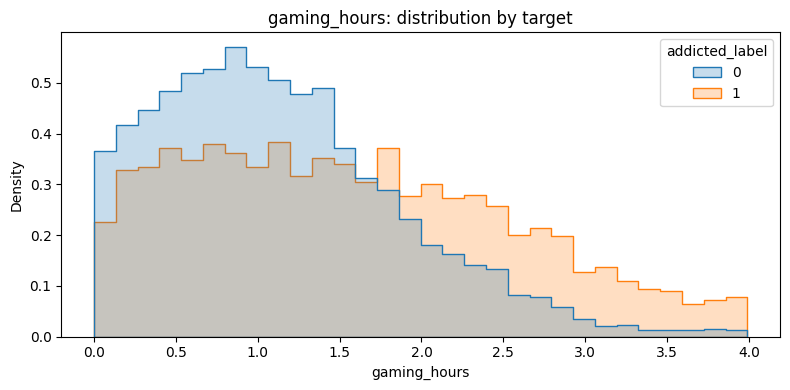

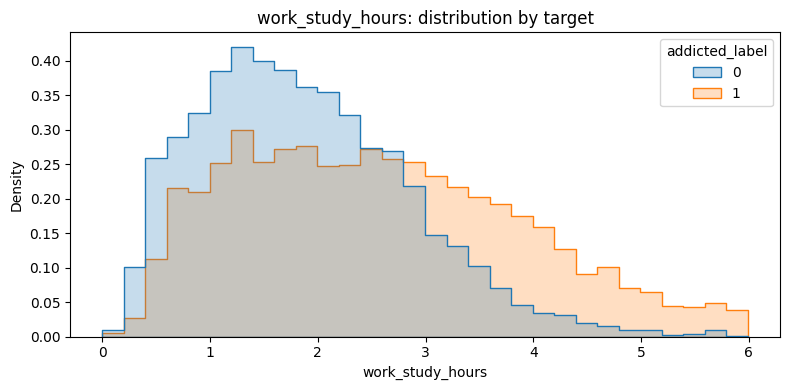

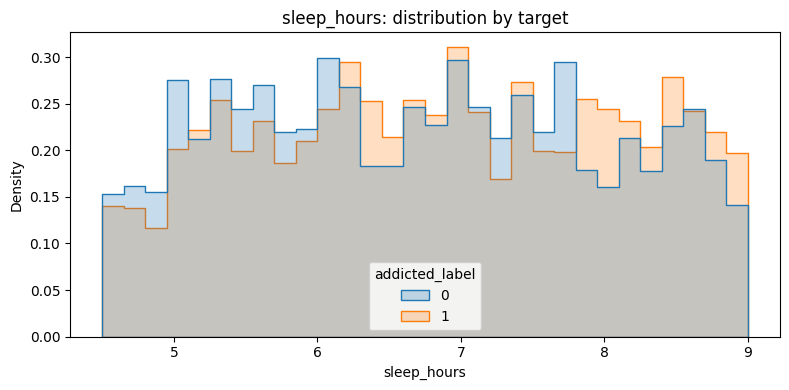

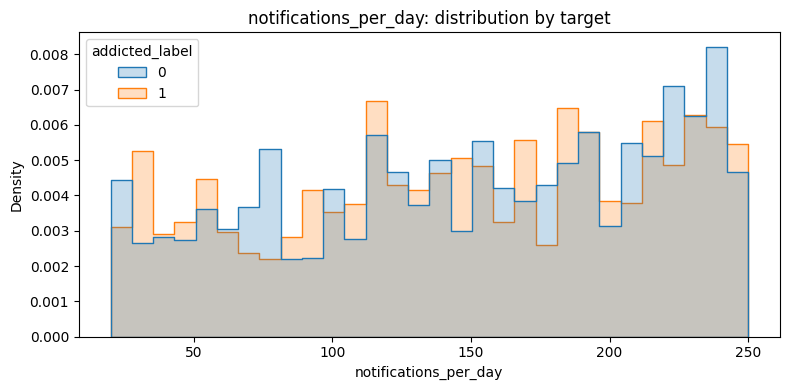

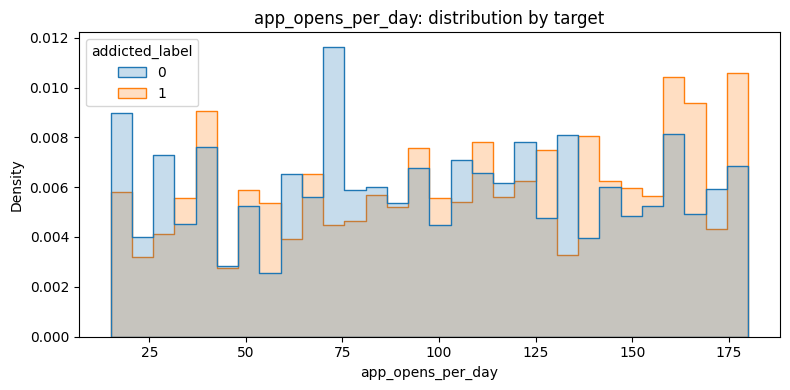

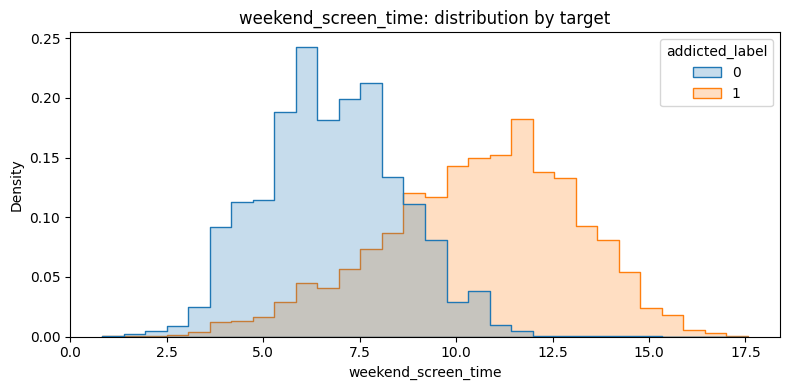

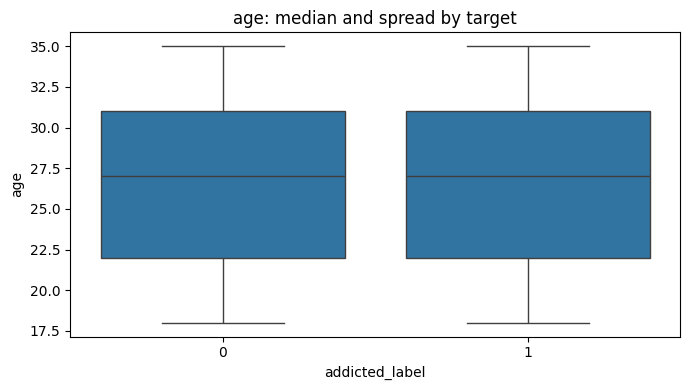

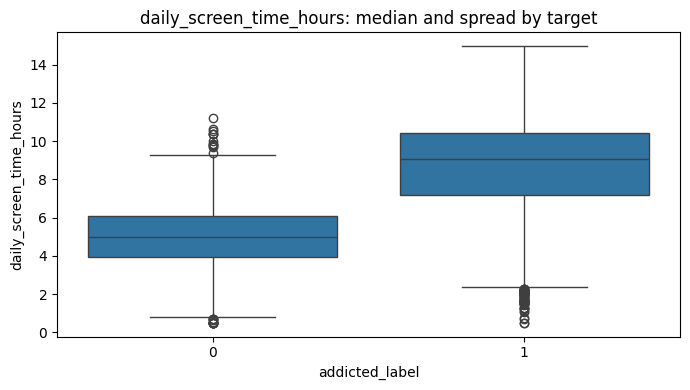

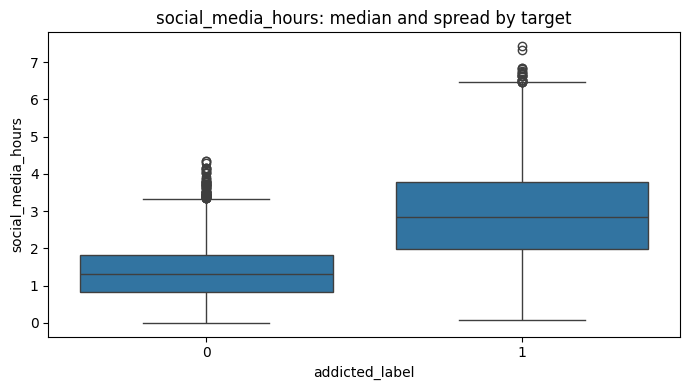

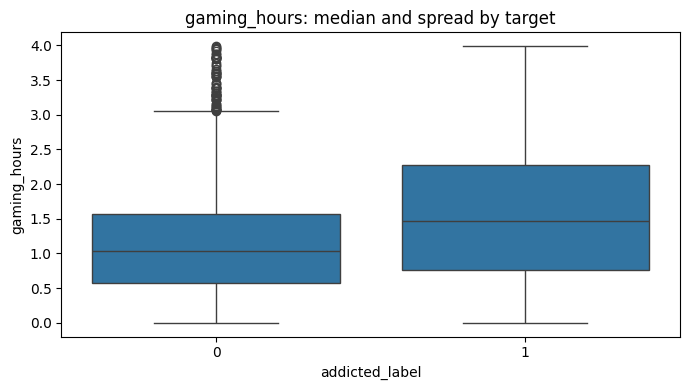

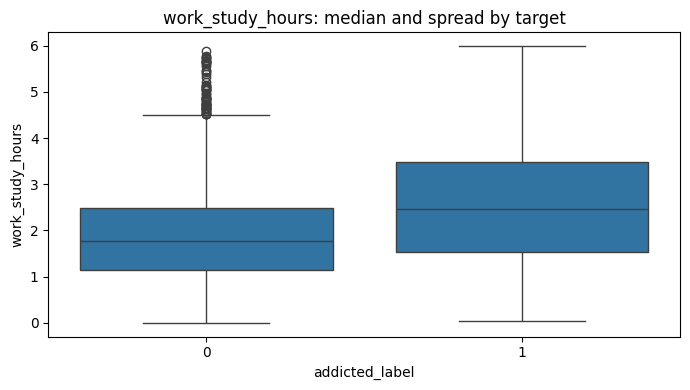

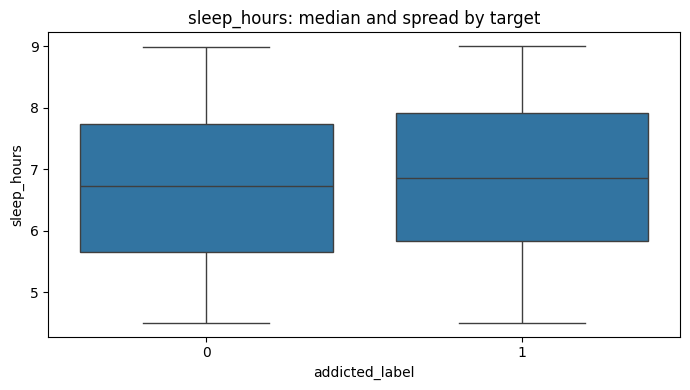

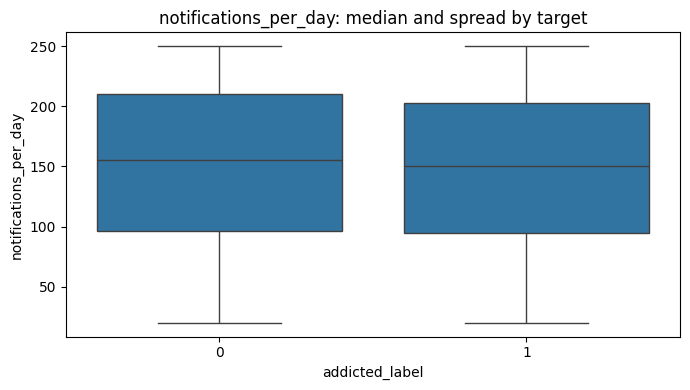

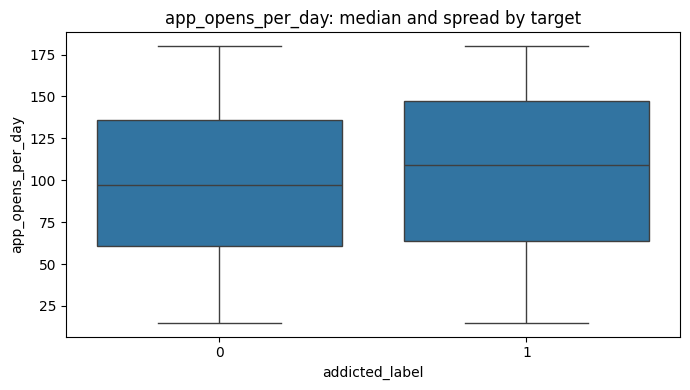

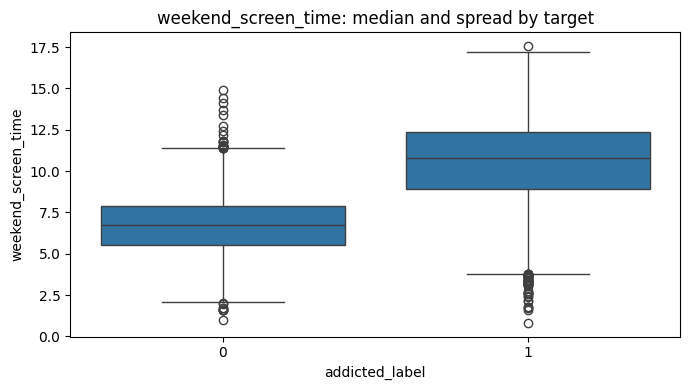

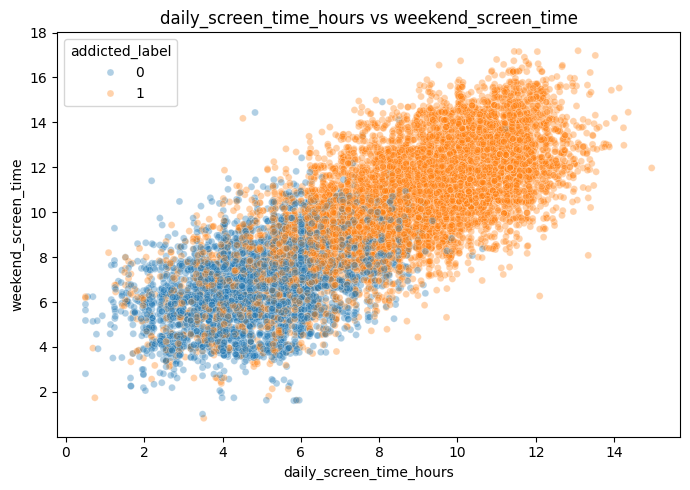

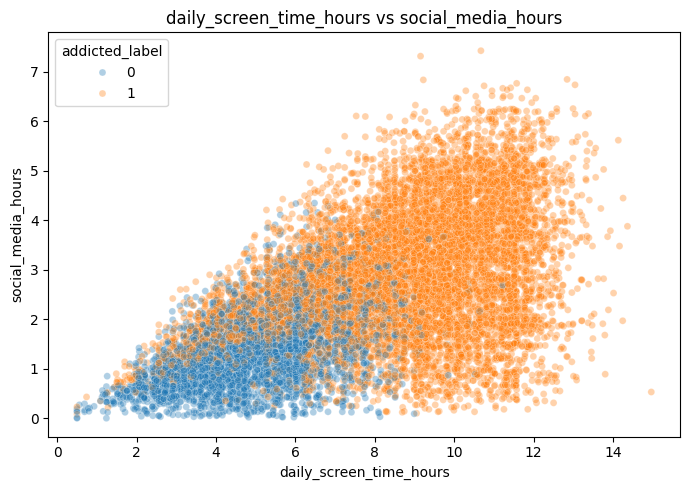

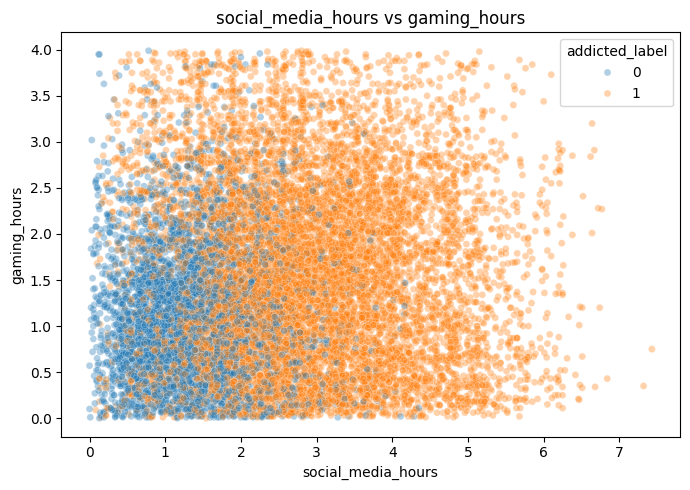

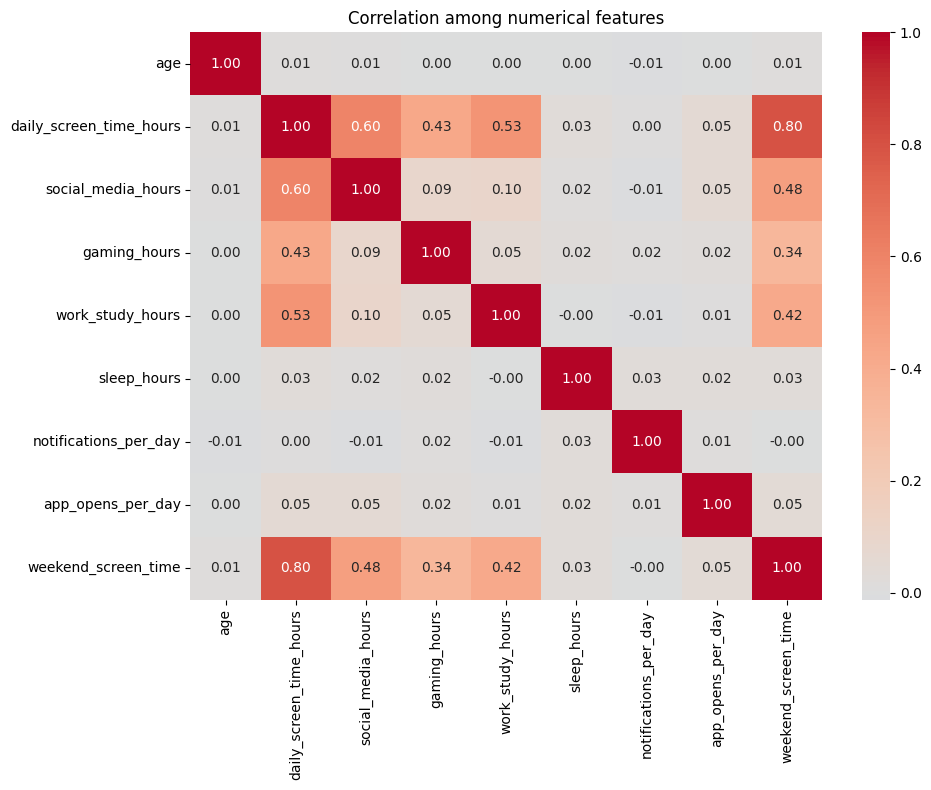

In [7]:
# Visual numerical feature analysis
# Use a sample for faster, clearer plots while keeping the summary statistics exact.
plot_data = train.sample(n=min(20000, len(train)), random_state=42)

print("MEANS AND MEDIANS BY TARGET")
print(train.groupby(target)[numeric_features].agg(["mean", "median"]).round(2))

# Histograms show the full distribution for each target class.
for column in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(
        data=plot_data,
        x=column,
        hue=target,
        bins=30,
        element="step",
        stat="density",
        common_norm=False,
    )
    plt.title(f"{column}: distribution by target")
    plt.tight_layout()
    plt.show()

# Boxplots make median, spread, and possible outliers easy to compare.
for column in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=plot_data, x=target, y=column)
    plt.title(f"{column}: median and spread by target")
    plt.tight_layout()
    plt.show()

# Scatter plots show whether relationships between important variables look linear.
scatter_pairs = [
    ("daily_screen_time_hours", "weekend_screen_time"),
    ("daily_screen_time_hours", "social_media_hours"),
    ("social_media_hours", "gaming_hours"),
]

for x_column, y_column in scatter_pairs:
    scatter_data = plot_data[[x_column, y_column, target]].dropna()
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=scatter_data,
        x=x_column,
        y=y_column,
        hue=target,
        alpha=0.35,
        s=25,
    )
    plt.title(f"{x_column} vs {y_column}")
    plt.tight_layout()
    plt.show()

# This heatmap measures linear relationships among numerical features.
plt.figure(figsize=(10, 8))
sns.heatmap(
    train[numeric_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)
plt.title("Correlation among numerical features")
plt.tight_layout()
plt.show()

OUTLIER SUMMARY USING IQR RULE
Rule: value < Q1 - 1.5*IQR OR value > Q3 + 1.5*IQR
Train rows: 691,369
Numeric features checked: 9


,feature,outlier_count,outlier_percent,min,q1,median,q3,max,skewness,target_rate_outliers,target_rate_non_outliers,target_rate_difference
0,social_media_hours,1209,0.1749,0.00,1.45,2.31,3.37,8.00,0.4681,1.0000,0.7089,0.2911
1,work_study_hours,300,0.0434,0.00,1.36,2.20,3.20,6.00,0.5635,0.9767,0.7093,0.2674
2,weekend_screen_time,6,0.0009,0.51,7.28,9.58,11.75,17.56,-0.0634,0.3333,0.7094,-0.3761
3,age,0,0.0000,18.00,22.00,27.00,31.00,35.00,-0.0368,NaN,0.7094,NaN
4,daily_screen_time_hours,0,0.0000,0.50,5.48,7.77,9.84,15.00,-0.1320,NaN,0.7094,NaN
5,gaming_hours,0,0.0000,0.00,0.70,1.33,2.09,4.00,0.5447,NaN,0.7094,NaN
6,sleep_hours,0,0.0000,4.50,5.78,6.80,7.87,9.00,-0.0066,NaN,0.7094,NaN
7,notifications_per_day,0,0.0000,20.00,93.00,150.00,204.00,250.00,-0.2065,NaN,0.7094,NaN
8,app_opens_per_day,0,0.0000,15.00,64.00,104.00,145.00,180.00,-0.1265,NaN,0.7094,NaN


Saved outlier_summary.csv


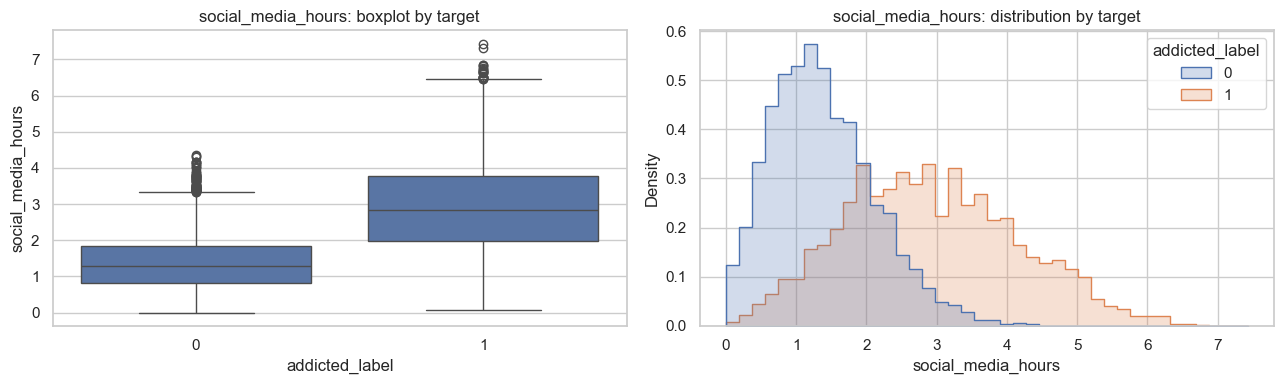

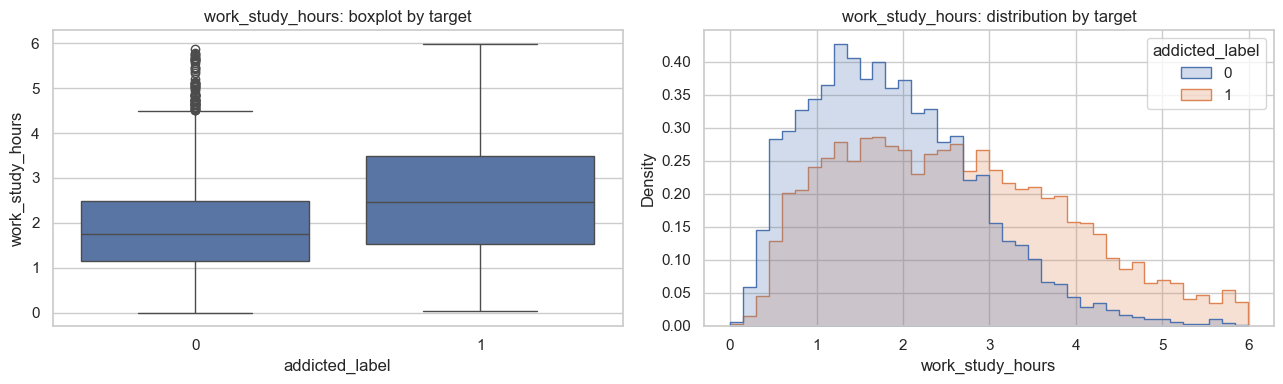

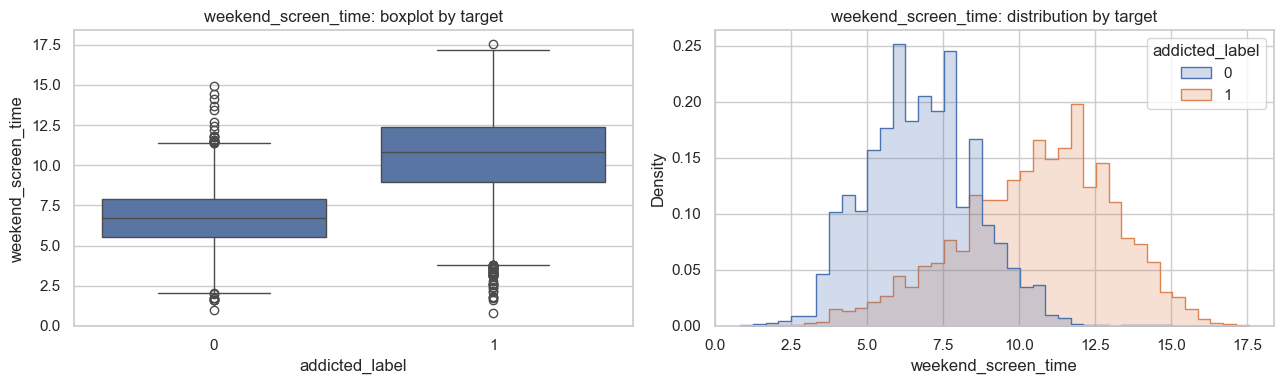

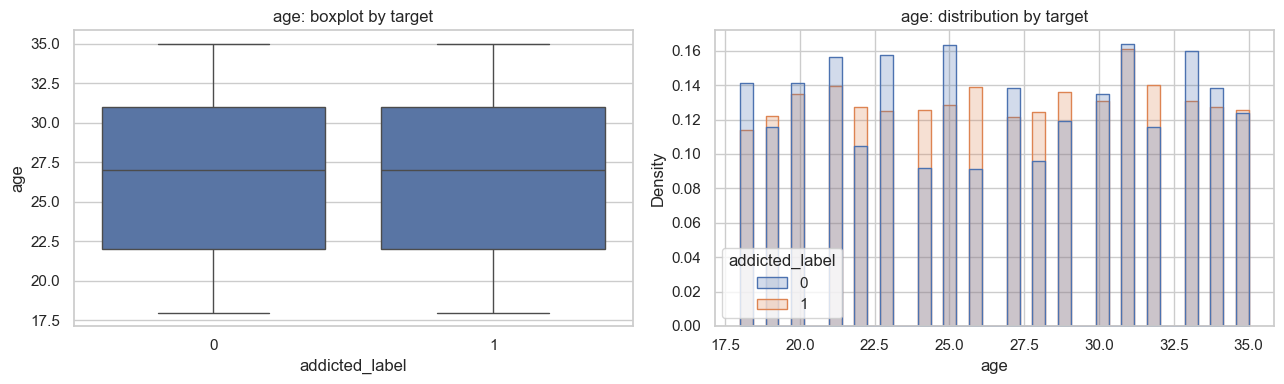

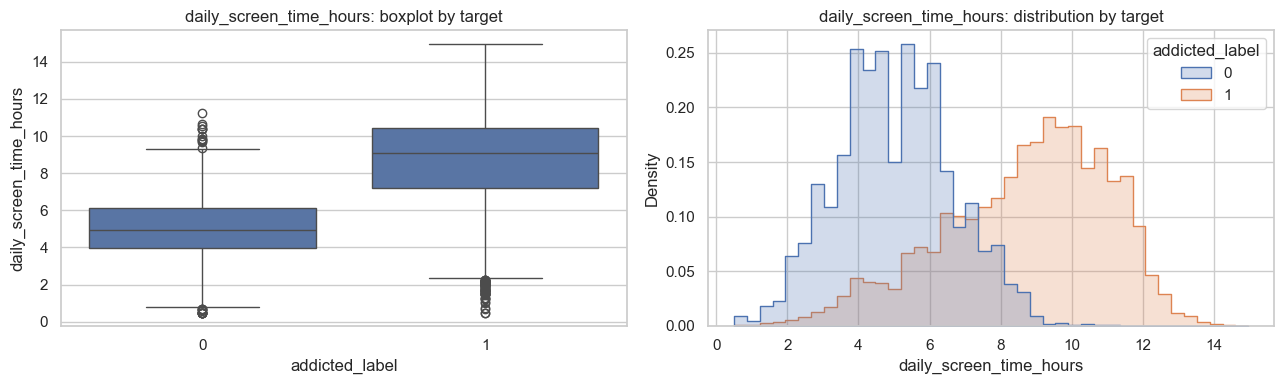

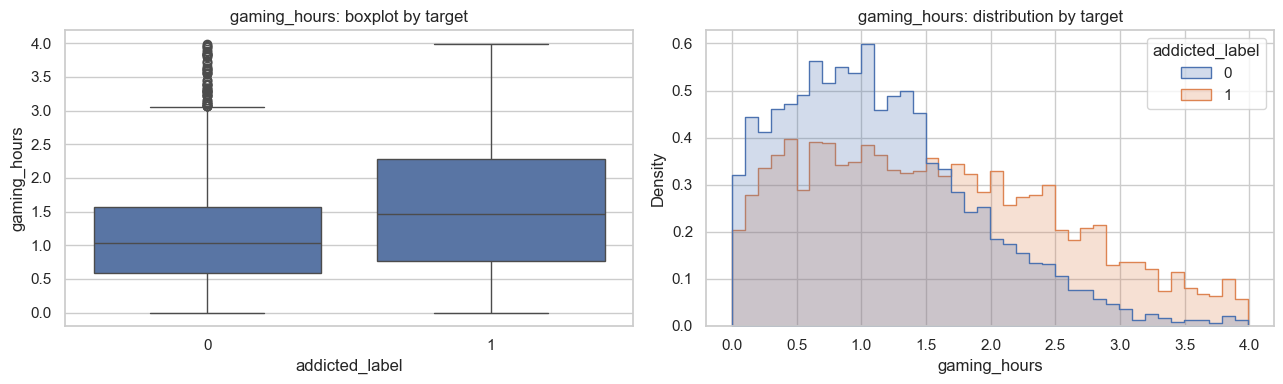

Top columns by outlier percentage:


,feature,outlier_percent,target_rate_difference,lower_bound,upper_bound
0,social_media_hours,0.1749,0.2911,-1.430,6.250
1,work_study_hours,0.0434,0.2674,-1.400,5.960
2,weekend_screen_time,0.0009,-0.3761,0.575,18.455
3,age,0.0000,NaN,8.500,44.500
4,daily_screen_time_hours,0.0000,NaN,-1.060,16.380
5,gaming_hours,0.0000,NaN,-1.385,4.175
6,sleep_hours,0.0000,NaN,2.645,11.005
7,notifications_per_day,0.0000,NaN,-73.500,370.500
8,app_opens_per_day,0.0000,NaN,-57.500,266.500


In [1]:
# Outlier Analysis - EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_DIR = Path("playground-series-s6e8")
target = "addicted_label"

train_outlier = pd.read_csv(DATA_DIR / "train.csv")

numeric_features_outlier = (
    train_outlier
    .select_dtypes(include="number")
    .columns
    .drop(["id", target], errors="ignore")
    .tolist()
)

outlier_rows = []

for column in numeric_features_outlier:
    series = train_outlier[column].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (train_outlier[column] < lower_bound)
        | (train_outlier[column] > upper_bound)
    )

    outlier_count = int(outlier_mask.sum())
    outlier_percent = outlier_count / len(train_outlier) * 100
    outlier_target_rate = train_outlier.loc[outlier_mask, target].mean()
    non_outlier_target_rate = train_outlier.loc[~outlier_mask, target].mean()

    outlier_rows.append({
        "feature": column,
        "missing_count": int(train_outlier[column].isna().sum()),
        "missing_percent": train_outlier[column].isna().mean() * 100,
        "min": series.min(),
        "q1": q1,
        "median": series.median(),
        "q3": q3,
        "max": series.max(),
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percent": outlier_percent,
        "skewness": series.skew(),
        "target_rate_outliers": outlier_target_rate,
        "target_rate_non_outliers": non_outlier_target_rate,
        "target_rate_difference": outlier_target_rate - non_outlier_target_rate,
    })

outlier_summary = (
    pd.DataFrame(outlier_rows)
    .sort_values("outlier_percent", ascending=False)
    .reset_index(drop=True)
)

print("OUTLIER SUMMARY USING IQR RULE")
print("Rule: value < Q1 - 1.5*IQR OR value > Q3 + 1.5*IQR")
print(f"Train rows: {len(train_outlier):,}")
print(f"Numeric features checked: {len(numeric_features_outlier)}")

display_columns = [
    "feature",
    "outlier_count",
    "outlier_percent",
    "min",
    "q1",
    "median",
    "q3",
    "max",
    "skewness",
    "target_rate_outliers",
    "target_rate_non_outliers",
    "target_rate_difference",
]

display(outlier_summary[display_columns].round(4))

outlier_summary.to_csv("outlier_summary.csv", index=False)
print("Saved outlier_summary.csv")

top_features = outlier_summary.head(6)["feature"].tolist()
plot_data = train_outlier.sample(n=min(20000, len(train_outlier)), random_state=42)

for column in top_features:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    sns.boxplot(data=plot_data, x=target, y=column, ax=axes[0])
    axes[0].set_title(f"{column}: boxplot by target")

    sns.histplot(
        data=plot_data,
        x=column,
        hue=target,
        bins=40,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[1],
    )
    axes[1].set_title(f"{column}: distribution by target")

    plt.tight_layout()
    plt.show()

print("Top columns by outlier percentage:")
display(
    outlier_summary[
        [
            "feature",
            "outlier_percent",
            "target_rate_difference",
            "lower_bound",
            "upper_bound",
        ]
    ]
    .head(10)
    .round(4)
)


In [1]:
# Data Quality / Sanity Checks - EDA
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path("playground-series-s6e8")
target = "addicted_label"

train_quality = pd.read_csv(DATA_DIR / "train.csv")
test_quality = pd.read_csv(DATA_DIR / "test.csv")
sample_submission_quality = pd.read_csv(DATA_DIR / "sample_submission.csv")

numeric_columns = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time",
]

categorical_columns = [
    "gender",
    "stress_level",
    "academic_work_impact",
]

print("BASIC SHAPE CHECKS")
print("Train shape:", train_quality.shape)
print("Test shape:", test_quality.shape)
print("Sample submission shape:", sample_submission_quality.shape)
print("Train columns:", train_quality.columns.tolist())
print("Test columns:", test_quality.columns.tolist())

print("\nID CHECKS")
print("Train id unique:", train_quality["id"].is_unique)
print("Test id unique:", test_quality["id"].is_unique)
print("Train/Test id overlap:", train_quality["id"].isin(test_quality["id"]).sum())
print("Sample submission ids match test ids:", sample_submission_quality["id"].equals(test_quality["id"]))

print("\nDUPLICATE ROW CHECKS")
print("Exact duplicate train rows:", train_quality.duplicated().sum())
print("Exact duplicate test rows:", test_quality.duplicated().sum())
print(
    "Duplicate train feature rows without id/target:",
    train_quality.drop(columns=["id", target]).duplicated().sum(),
)
print(
    "Duplicate test feature rows without id:",
    test_quality.drop(columns=["id"]).duplicated().sum(),
)

print("\nTARGET CHECKS")
print(train_quality[target].value_counts(dropna=False).sort_index())
print("Target rate:", round(train_quality[target].mean(), 5))

print("\nMISSING VALUE COMPARISON")
missing_summary = pd.DataFrame({
    "train_missing_count": train_quality.isna().sum(),
    "train_missing_percent": train_quality.isna().mean() * 100,
    "test_missing_count": test_quality.isna().sum(),
    "test_missing_percent": test_quality.isna().mean() * 100,
})
display(missing_summary.round(3))

print("\nNUMERIC RANGE CHECKS")
expected_ranges = {
    "age": (0, 120),
    "daily_screen_time_hours": (0, 24),
    "social_media_hours": (0, 24),
    "gaming_hours": (0, 24),
    "work_study_hours": (0, 24),
    "sleep_hours": (0, 24),
    "notifications_per_day": (0, None),
    "app_opens_per_day": (0, None),
    "weekend_screen_time": (0, 24),
}

range_rows = []
for column, (minimum_allowed, maximum_allowed) in expected_ranges.items():
    train_series = train_quality[column]
    test_series = test_quality[column]

    train_bad = pd.Series(False, index=train_quality.index)
    test_bad = pd.Series(False, index=test_quality.index)

    if minimum_allowed is not None:
        train_bad |= train_series < minimum_allowed
        test_bad |= test_series < minimum_allowed
    if maximum_allowed is not None:
        train_bad |= train_series > maximum_allowed
        test_bad |= test_series > maximum_allowed

    range_rows.append({
        "feature": column,
        "expected_min": minimum_allowed,
        "expected_max": maximum_allowed,
        "train_min": train_series.min(),
        "train_max": train_series.max(),
        "test_min": test_series.min(),
        "test_max": test_series.max(),
        "train_invalid_count": int(train_bad.sum()),
        "test_invalid_count": int(test_bad.sum()),
    })

range_summary = pd.DataFrame(range_rows)
display(range_summary)

print("\nCATEGORICAL LEVEL CHECKS")
category_rows = []
for column in categorical_columns:
    train_levels = set(train_quality[column].dropna().unique())
    test_levels = set(test_quality[column].dropna().unique())
    category_rows.append({
        "feature": column,
        "train_levels": sorted(train_levels),
        "test_levels": sorted(test_levels),
        "levels_only_in_train": sorted(train_levels - test_levels),
        "levels_only_in_test": sorted(test_levels - train_levels),
    })

category_summary = pd.DataFrame(category_rows)
display(category_summary)

print("\nLOGICAL CONSISTENCY CHECKS")
logic_checks = {
    "recreational_hours_greater_than_daily_screen": (
        (train_quality["social_media_hours"].fillna(0) + train_quality["gaming_hours"].fillna(0))
        > train_quality["daily_screen_time_hours"]
    ),
    "tracked_screen_hours_greater_than_daily_screen": (
        (
            train_quality["social_media_hours"].fillna(0)
            + train_quality["gaming_hours"].fillna(0)
            + train_quality["work_study_hours"].fillna(0)
        )
        > train_quality["daily_screen_time_hours"]
    ),
    "daily_plus_sleep_greater_than_24": (
        train_quality["daily_screen_time_hours"] + train_quality["sleep_hours"] > 24
    ),
    "weekend_plus_sleep_greater_than_24": (
        train_quality["weekend_screen_time"] + train_quality["sleep_hours"] > 24
    ),
}

logic_summary = []
for check_name, mask in logic_checks.items():
    logic_summary.append({
        "check": check_name,
        "count": int(mask.sum()),
        "percent": mask.mean() * 100,
        "target_rate_in_flagged_rows": train_quality.loc[mask, target].mean(),
        "target_rate_in_other_rows": train_quality.loc[~mask, target].mean(),
    })

logic_summary = pd.DataFrame(logic_summary)
display(logic_summary.round(4))

print("\nTRAIN VS TEST DISTRIBUTION DRIFT QUICK CHECK")
drift_rows = []
for column in numeric_columns:
    train_median = train_quality[column].median()
    test_median = test_quality[column].median()
    train_iqr = train_quality[column].quantile(0.75) - train_quality[column].quantile(0.25)
    drift_rows.append({
        "feature": column,
        "train_mean": train_quality[column].mean(),
        "test_mean": test_quality[column].mean(),
        "mean_difference": test_quality[column].mean() - train_quality[column].mean(),
        "train_median": train_median,
        "test_median": test_median,
        "median_difference": test_median - train_median,
        "difference_vs_train_iqr": (test_median - train_median) / train_iqr if train_iqr != 0 else np.nan,
    })

drift_summary = pd.DataFrame(drift_rows).sort_values(
    "difference_vs_train_iqr",
    key=lambda values: values.abs(),
    ascending=False,
)
display(drift_summary.round(4))

missing_summary.to_csv("data_quality_missing_summary.csv")
range_summary.to_csv("data_quality_range_summary.csv", index=False)
category_summary.to_csv("data_quality_category_summary.csv", index=False)
logic_summary.to_csv("data_quality_logic_summary.csv", index=False)
drift_summary.to_csv("data_quality_drift_summary.csv", index=False)

print("\nSaved data quality summary CSV files.")


BASIC SHAPE CHECKS
Train shape: (691369, 14)
Test shape: (296302, 13)
Sample submission shape: (296302, 2)
Train columns: ['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact', 'addicted_label']
Test columns: ['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact']

ID CHECKS
Train id unique: True
Test id unique: True


Train/Test id overlap: 0
Sample submission ids match test ids: True

DUPLICATE ROW CHECKS


Exact duplicate train rows: 0


Exact duplicate test rows: 0


Duplicate train feature rows without id/target: 0


...


LOGICAL CONSISTENCY CHECKS


,check,count,percent,target_rate_in_flagged_rows,target_rate_in_other_rows
0,recreational_hours_greater_than_daily_screen,0,0.0000,NaN,0.7094
1,tracked_screen_hours_greater_than_daily_screen,0,0.0000,NaN,0.7094
2,daily_plus_sleep_greater_than_24,0,0.0000,NaN,0.7094
3,weekend_plus_sleep_greater_than_24,978,0.1415,1.0,0.7090



TRAIN VS TEST DISTRIBUTION DRIFT QUICK CHECK


,feature,train_mean,test_mean,mean_difference,train_median,test_median,median_difference,difference_vs_train_iqr
2,social_media_hours,2.4710,2.4712,0.0002,2.31,2.32,0.01,0.0052
0,age,26.6154,26.6087,-0.0067,27.00,27.00,0.00,0.0000
1,daily_screen_time_hours,7.6409,7.6408,-0.0001,7.77,7.77,0.00,0.0000
3,gaming_hours,1.4593,1.4577,-0.0016,1.33,1.33,0.00,0.0000
4,work_study_hours,2.3670,2.3660,-0.0010,2.20,2.20,0.00,0.0000
5,sleep_hours,6.8043,6.8017,-0.0026,6.80,6.80,0.00,0.0000
6,notifications_per_day,145.8949,145.7481,-0.1468,150.00,150.00,0.00,0.0000
7,app_opens_per_day,102.6368,102.6562,0.0194,104.00,104.00,0.00,0.0000
8,weekend_screen_time,9.4799,9.4746,-0.0053,9.58,9.58,0.00,0.0000



Saved data quality summary CSV files.


In [1]:
# Feature Engineering
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path("playground-series-s6e8")
target = "addicted_label"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

raw_numeric_features = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time",
]

raw_categorical_features = [
    "gender",
    "stress_level",
    "academic_work_impact",
]


def safe_divide(numerator, denominator, offset=1.0):
    return numerator / (denominator + offset)


def build_features(data):
    data = data.copy()

    social = data["social_media_hours"].fillna(0)
    gaming = data["gaming_hours"].fillna(0)
    work_study = data["work_study_hours"].fillna(0)
    sleep = data["sleep_hours"].fillna(0)

    # Missingness can be predictive in this synthetic Kaggle dataset.
    for column in raw_numeric_features + raw_categorical_features:
        data[f"{column}_missing"] = data[column].isna().astype("int8")

    # Behavior totals.
    data["total_recreational_hours"] = social + gaming
    data["total_screen_related_hours"] = social + gaming + work_study
    data["total_tracked_hours"] = social + gaming + work_study + sleep

    # Differences and balances.
    data["weekend_minus_daily_screen"] = (
        data["weekend_screen_time"] - data["daily_screen_time_hours"]
    )
    data["daily_minus_weekend_screen"] = (
        data["daily_screen_time_hours"] - data["weekend_screen_time"]
    )
    data["recreational_minus_work_hours"] = (
        data["total_recreational_hours"] - work_study
    )
    data["screen_balance"] = (
        data["daily_screen_time_hours"] - social - gaming - work_study
    )
    data["sleep_deficit_from_8"] = 8 - data["sleep_hours"]

    # Ratios and intensity features.
    data["weekend_to_daily_ratio"] = safe_divide(
        data["weekend_screen_time"], data["daily_screen_time_hours"], offset=0.1
    )
    data["social_media_share"] = safe_divide(
        data["social_media_hours"], data["daily_screen_time_hours"], offset=0.1
    )
    data["gaming_share"] = safe_divide(
        data["gaming_hours"], data["daily_screen_time_hours"], offset=0.1
    )
    data["work_study_share"] = safe_divide(
        data["work_study_hours"], data["daily_screen_time_hours"], offset=0.1
    )
    data["recreational_share"] = safe_divide(
        data["total_recreational_hours"], data["daily_screen_time_hours"], offset=0.1
    )
    data["screen_time_per_app_open"] = safe_divide(
        data["daily_screen_time_hours"], data["app_opens_per_day"], offset=1.0
    )
    data["notifications_per_app_open"] = safe_divide(
        data["notifications_per_day"], data["app_opens_per_day"], offset=1.0
    )
    data["notifications_per_screen_hour"] = safe_divide(
        data["notifications_per_day"], data["daily_screen_time_hours"], offset=1.0
    )
    data["sleep_to_screen_ratio"] = safe_divide(
        data["sleep_hours"], data["daily_screen_time_hours"], offset=0.1
    )

    # EDA-driven outlier/sanity flags.
    data["high_social_media_flag"] = (data["social_media_hours"] > 6.25).astype("int8")
    data["high_work_study_flag"] = (data["work_study_hours"] > 5.96).astype("int8")
    data["weekend_sleep_over_24_flag"] = (
        data["weekend_screen_time"] + data["sleep_hours"] > 24
    ).astype("int8")

    # Binned and interaction categorical features.
    data["age_group"] = pd.cut(
        data["age"],
        bins=[0, 18, 21, 24, 27, 30, 100],
        labels=["under_18", "18_21", "21_24", "24_27", "27_30", "30_plus"],
    )
    data["screen_time_level"] = pd.cut(
        data["daily_screen_time_hours"],
        bins=[0, 4, 7, 10, 24],
        labels=["low", "medium", "high", "very_high"],
    )
    data["sleep_level"] = pd.cut(
        data["sleep_hours"],
        bins=[0, 6, 7.5, 24],
        labels=["low_sleep", "normal_sleep", "high_sleep"],
    )

    data["gender_stress"] = (
        data["gender"].fillna("Missing") + "_" + data["stress_level"].fillna("Missing")
    )
    data["stress_impact"] = (
        data["stress_level"].fillna("Missing")
        + "_"
        + data["academic_work_impact"].fillna("Missing")
    )
    data["gender_impact"] = (
        data["gender"].fillna("Missing")
        + "_"
        + data["academic_work_impact"].fillna("Missing")
    )
    data["screen_stress"] = (
        data["screen_time_level"].astype("object").fillna("Missing").astype(str)
        + "_"
        + data["stress_level"].fillna("Missing")
    )

    return data


train_fe = build_features(train.drop(columns=[target]))
test_fe = build_features(test)
y = train[target]

feature_columns = [column for column in train_fe.columns if column != "id"]
numeric_feature_columns = (
    train_fe[feature_columns]
    .select_dtypes(include="number")
    .columns
    .tolist()
)
categorical_feature_columns = [
    column for column in feature_columns if column not in numeric_feature_columns
]

# Keep categorical columns consistent between train and test for the modeling step.
for column in categorical_feature_columns:
    train_values = train_fe[column].astype("object").where(train_fe[column].notna(), "Missing")
    test_values = test_fe[column].astype("object").where(test_fe[column].notna(), "Missing")
    categories = pd.Index(pd.concat([train_values, test_values], axis=0).unique())
    train_fe[column] = pd.Categorical(train_values, categories=categories)
    test_fe[column] = pd.Categorical(test_values, categories=categories)

new_feature_columns = [
    column
    for column in feature_columns
    if column not in raw_numeric_features + raw_categorical_features
]

print("FEATURE ENGINEERING SUMMARY")
print("Train engineered shape:", train_fe.shape)
print("Test engineered shape:", test_fe.shape)
print("Original usable features:", len(raw_numeric_features) + len(raw_categorical_features))
print("Total model features:", len(feature_columns))
print("New engineered features:", len(new_feature_columns))
print("Numeric features:", len(numeric_feature_columns))
print("Categorical features:", len(categorical_feature_columns))

feature_summary = pd.DataFrame({
    "feature": feature_columns,
    "dtype": [str(train_fe[column].dtype) for column in feature_columns],
    "train_missing_percent": [train_fe[column].isna().mean() * 100 for column in feature_columns],
    "test_missing_percent": [test_fe[column].isna().mean() * 100 for column in feature_columns],
    "train_unique": [train_fe[column].nunique(dropna=False) for column in feature_columns],
    "test_unique": [test_fe[column].nunique(dropna=False) for column in feature_columns],
})

print("\nNew engineered feature names:")
display(pd.DataFrame({"new_feature": new_feature_columns}))

print("\nFeature summary sample:")
display(feature_summary.head(25).round(3))

print("\nEDA-driven flag target rates:")
flag_columns = [
    "high_social_media_flag",
    "high_work_study_flag",
    "weekend_sleep_over_24_flag",
]
flag_summary = []
for column in flag_columns:
    flag_summary.append({
        "feature": column,
        "flagged_rows": int(train_fe[column].sum()),
        "flagged_percent": train_fe[column].mean() * 100,
        "target_rate_when_flagged": y[train_fe[column] == 1].mean(),
        "target_rate_when_not_flagged": y[train_fe[column] == 0].mean(),
    })
flag_summary = pd.DataFrame(flag_summary)
display(flag_summary.round(4))

print("\nTrain/test column alignment:", train_fe[feature_columns].columns.equals(test_fe[feature_columns].columns))
print("Feature engineering objects ready: train_fe, test_fe, y, feature_columns, numeric_feature_columns, categorical_feature_columns")

feature_summary.to_csv("feature_engineering_summary.csv", index=False)
flag_summary.to_csv("feature_engineering_flag_summary.csv", index=False)
print("Saved feature_engineering_summary.csv")
print("Saved feature_engineering_flag_summary.csv")


FEATURE ENGINEERING SUMMARY
Train engineered shape: (691369, 52)
Test engineered shape: (296302, 52)
Original usable features: 12
Total model features: 51
New engineered features: 39
Numeric features: 41
Categorical features: 10



New engineered feature names:


,new_feature
0,age_missing
1,daily_screen_time_hours_missing
2,social_media_hours_missing
3,gaming_hours_missing
4,work_study_hours_missing
5,sleep_hours_missing
6,notifications_per_day_missing
7,app_opens_per_day_missing
8,weekend_screen_time_missing
9,gender_missing



Feature summary sample:


,feature,dtype,train_missing_percent,test_missing_percent,train_unique,test_unique
0,age,float64,4.184,5.784,19,19
1,daily_screen_time_hours,float64,13.864,11.066,1390,1350
2,social_media_hours,float64,19.381,15.996,722,704
3,gaming_hours,float64,18.343,20.054,402,402
4,work_study_hours,float64,7.452,9.375,601,602
5,sleep_hours,float64,6.434,7.578,452,452
6,notifications_per_day,float64,9.775,11.549,232,232
7,app_opens_per_day,float64,11.674,8.675,167,167
8,weekend_screen_time,float64,16.209,17.110,1438,1405
9,gender,category,0.000,0.000,4,4



EDA-driven flag target rates:


,feature,flagged_rows,flagged_percent,target_rate_when_flagged,target_rate_when_not_flagged
0,high_social_media_flag,1209,0.1749,1.0000,0.7089
1,high_work_study_flag,300,0.0434,0.9767,0.7093
2,weekend_sleep_over_24_flag,978,0.1415,1.0000,0.7090



Train/test column alignment: True
Feature engineering objects ready: train_fe, test_fe, y, feature_columns, numeric_feature_columns, categorical_feature_columns


Saved feature_engineering_summary.csv
Saved feature_engineering_flag_summary.csv
